In [3]:
# !pip install yfinance
# !pip install TA-Lib 
# !pip install numpy
# !pip install pandas
# !pip install vectorbt
# !pip install scipy

In [4]:
import yfinance as yf
import talib
import numpy as np
import pandas as pd
import vectorbt as vbt
import warnings
from scipy import stats
import matplotlib.pyplot as plt
from tqdm import tqdm


In [5]:
# DOWNLOAD STOCK DATA FROM 2018 USING YFINANCE

# Configuration - Change these variables as needed
TICKER = 'BTC-USD'  # Any ticker symbol (e.g., 'AAPL', 'MSFT', 'GOOGL')
START_DATE = '2017-01-01'
END_DATE = '2024-06-21'

# Download data from start date onwards
DATA_PATH = r"data/QQQ.csv"
stock_data = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)

stock_data = stock_data.loc[START_DATE:END_DATE]

if not stock_data.empty:
    print(f"Successfully downloaded {len(stock_data)} records for {TICKER} from {START_DATE}")
    print(f"Data range: {stock_data.index.min().date()} to {stock_data.index.max().date()}")
    print("\nFirst 5 rows:")
    print(stock_data.head())
else:
    print(f"Failed to download {TICKER} data from yfinance")

# Display the downloaded data
stock_data


Successfully downloaded 1879 records for BTC-USD from 2017-01-01
Data range: 2017-01-03 to 2024-06-21

First 5 rows:
                  open        high         low       close    adjclose  \
2017-01-03  119.269997  119.989998  118.889999  119.540001  113.513687   
2017-01-04  119.669998  120.410004  119.660004  120.190002  114.130913   
2017-01-05  120.099998  120.949997  120.099998  120.870003  114.776634   
2017-01-06  121.000000  122.250000  120.690002  121.930000  115.783188   
2017-01-09  122.029999  122.550003  121.949997  122.330002  116.163025   

              volume ticker  
2017-01-03  22307600    QQQ  
2017-01-04  19749100    QQQ  
2017-01-05  20644300    QQQ  
2017-01-06  24074300    QQQ  
2017-01-09  18909200    QQQ  


,open,high,low,close,adjclose,volume,ticker
2017-01-03,119.269997,119.989998,118.889999,119.540001,113.513687,22307600,QQQ
2017-01-04,119.669998,120.410004,119.660004,120.190002,114.130913,19749100,QQQ
2017-01-05,120.099998,120.949997,120.099998,120.870003,114.776634,20644300,QQQ
2017-01-06,121.000000,122.250000,120.690002,121.930000,115.783188,24074300,QQQ
2017-01-09,122.029999,122.550003,121.949997,122.330002,116.163025,18909200,QQQ
...,...,...,...,...,...,...,...
2024-06-14,476.519989,479.260010,476.049988,479.190002,479.190002,23372600,QQQ
2024-06-17,479.459991,486.859985,478.140015,485.059998,485.059998,37054500,QQQ
2024-06-18,485.010010,485.899994,483.429993,485.209991,485.209991,24438600,QQQ
2024-06-20,486.420013,486.839996,479.619995,481.470001,481.470001,33760100,QQQ


In [6]:
# PREPARE PRICE SERIES

warnings.filterwarnings("ignore", message="Degrees of freedom <= 0 for slice", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="invalid value encountered in scalar divide", category=RuntimeWarning)

# Expect stock_data and TICKER already exist
def select_close_series(df, ticker):
    if isinstance(df.columns, pd.MultiIndex):
        if ('Close', ticker) in df.columns:
            s = df[('Close', ticker)]
        else:
            cols = [c for c in df.columns if 'Close' in str(c)]
            if not cols:
                raise KeyError("Close not found")
            s = df[cols[0]]
    else:
        try:
            s = df['Close']
        except KeyError:
            s = df['close']
    return s.astype(float).squeeze()

close = select_close_series(stock_data, TICKER)
close.name = 'price'

# Simple split
TRAIN_RATIO = 0.60 
split_idx = int(len(close) * TRAIN_RATIO)
train_close = close.iloc[:split_idx].copy()
val_close   = close.iloc[split_idx:].copy()

print(f"Data ready: train={train_close.index[0].date()} → {train_close.index[-1].date()} | val={val_close.index[0].date()} → {val_close.index[-1].date()}")

Data ready: train=2017-01-03 → 2021-06-24 | val=2021-06-25 → 2024-06-21


TRIPLE EMA CROSSOVER GRID SEARCH - TRAINING SET
----------------------------------------------

This section performs a comprehensive grid search optimization for the **Triple EMA Crossover Strategy** using only the **training data**.

The goal is to find the optimal EMA1/EMA2/EMA3 combination that maximizes the Sharpe ratio on unseen data.

**Strategy Logic**: Buy when any EMA crosses above another (EMA1 > EMA2, EMA1 > EMA3, or EMA2 > EMA3). Sell when any EMA crosses below another.

---

In [7]:
# Define Parameter Ranges for Triple EMA Crossover

# EMA periods for triple crossover strategy
ema1_periods = list(range(4, 40, 5))    # Fast EMA (shortest-term)
ema2_periods = list(range(50, 90, 5))  # Medium EMA (medium-term)
ema3_periods = list(range(120, 250, 5)) # Slow EMA (longest-term)



print("EMA1 Periods (fast - shortest-term):")
for i, period in enumerate(ema1_periods, 1):
    print(f"  {i}. {period} periods")

print("EMA2 Periods (medium - medium-term):")
for i, period in enumerate(ema2_periods, 1):
    print(f"  {i}. {period} periods")

print("EMA3 Periods (slow - longest-term):")
for i, period in enumerate(ema3_periods, 1):
    print(f"  {i}. {period} periods")

# Generate all valid combinations (ema1 < ema2 < ema3)
ema_combinations = []
for ema1 in ema1_periods:
    for ema2 in ema2_periods:
        for ema3 in ema3_periods:
            if ema1 < ema2 < ema3:
                ema_combinations.append((ema1, ema2, ema3))

print(f"Generated {len(ema_combinations)} valid Triple EMA combinations")
print("\n📋 First 10 combinations preview:")
for i, (ema1, ema2, ema3) in enumerate(ema_combinations[:10], 1):
    print(f"  {i:2d}. EMA1: {ema1:2d} | EMA2: {ema2:2d} | EMA3: {ema3:2d}")
if len(ema_combinations) > 10:
    print(f"   ... and {len(ema_combinations) - 10} more combinations")

print("Ready to test all combinations on training data!")

EMA1 Periods (fast - shortest-term):
  1. 4 periods
  2. 9 periods
  3. 14 periods
  4. 19 periods
  5. 24 periods
  6. 29 periods
  7. 34 periods
  8. 39 periods
EMA2 Periods (medium - medium-term):
  1. 50 periods
  2. 55 periods
  3. 60 periods
  4. 65 periods
  5. 70 periods
  6. 75 periods
  7. 80 periods
  8. 85 periods
EMA3 Periods (slow - longest-term):
  1. 120 periods
  2. 125 periods
  3. 130 periods
  4. 135 periods
  5. 140 periods
  6. 145 periods
  7. 150 periods
  8. 155 periods
  9. 160 periods
  10. 165 periods
  11. 170 periods
  12. 175 periods
  13. 180 periods
  14. 185 periods
  15. 190 periods
  16. 195 periods
  17. 200 periods
  18. 205 periods
  19. 210 periods
  20. 215 periods
  21. 220 periods
  22. 225 periods
  23. 230 periods
  24. 235 periods
  25. 240 periods
  26. 245 periods
Generated 1664 valid Triple EMA combinations

📋 First 10 combinations preview:
   1. EMA1:  4 | EMA2: 50 | EMA3: 120
   2. EMA1:  4 | EMA2: 50 | EMA3: 125
   3. EMA1:  4 | EMA2:

In [8]:
# Initialize Triple EMA Results Collection System

# Create empty list to store all backtest results
grid_search_results = []

print("Triple EMA Results Collection System Initialized")
print(f"   - Will test {len(ema_combinations)} Triple EMA combinations")
print("   - Results will be stored in 'grid_search_results' list")

# Define what metrics we will collect (All TradingView-style metrics)
metrics_to_collect = [
    # Strategy Parameters
    "ema1_period",
    "ema2_period", 
    "ema3_period",
    
    # Return Metrics
    "total_return",
    "annualized_return",
    "total_profit",
    
    # Risk-Adjusted Return Metrics
    "sharpe_ratio",
    "sortino_ratio",
    "calmar_ratio",
    "omega_ratio",
    "information_ratio",
    "tail_ratio",
    "deflated_sharpe_ratio",
    
    # Risk Metrics
    "max_drawdown",
    "volatility",
    "ulcer_index",
    
    # Trade Performance Metrics
    "win_rate",
    "total_trades",
    "avg_trade_duration",
    "expectancy",
    "profit_factor", 
    "sqn",
    
    # Win/Loss Analysis
    "payoff_ratio",
    "largest_win",
    "largest_loss",
    "avg_win_amount",
    "avg_loss_amount",
    "winning_streak",
    "losing_streak",
    
    # Additional Ratios
    "recovery_factor",
    "gain_to_pain_ratio",
    "serenity_index"
]

print("Metrics to collect for each Triple EMA combination:")
for i, metric in enumerate(metrics_to_collect, 1):
    print(f"  {i}. {metric.replace('_', ' ').title()}")

print("Ready to start the Triple EMA grid search!")


Triple EMA Results Collection System Initialized
   - Will test 1664 Triple EMA combinations
   - Results will be stored in 'grid_search_results' list
Metrics to collect for each Triple EMA combination:
  1. Ema1 Period
  2. Ema2 Period
  3. Ema3 Period
  4. Total Return
  5. Annualized Return
  6. Total Profit
  7. Sharpe Ratio
  8. Sortino Ratio
  9. Calmar Ratio
  10. Omega Ratio
  11. Information Ratio
  12. Tail Ratio
  13. Deflated Sharpe Ratio
  14. Max Drawdown
  15. Volatility
  16. Ulcer Index
  17. Win Rate
  18. Total Trades
  19. Avg Trade Duration
  20. Expectancy
  21. Profit Factor
  22. Sqn
  23. Payoff Ratio
  24. Largest Win
  25. Largest Loss
  26. Avg Win Amount
  27. Avg Loss Amount
  28. Winning Streak
  29. Losing Streak
  30. Recovery Factor
  31. Gain To Pain Ratio
  32. Serenity Index
Ready to start the Triple EMA grid search!


In [9]:
# VISUALIZE SIGNALS FOR ONE EXAMPLE

example_ema1, example_ema2, example_ema3 = 7, 93, 152
ema1_ma = vbt.MA.run(train_close, example_ema1, ewm=True).ma
ema2_ma = vbt.MA.run(train_close, example_ema2, ewm=True).ma
ema3_ma = vbt.MA.run(train_close, example_ema3, ewm=True).ma

# Triple EMA crossover signals
entries_1 = ema1_ma.vbt.crossed_above(ema2_ma).reindex(train_close.index).fillna(False)
entries_2 = ema1_ma.vbt.crossed_above(ema3_ma).reindex(train_close.index).fillna(False)
entries_3 = ema2_ma.vbt.crossed_above(ema3_ma).reindex(train_close.index).fillna(False)
entries = entries_1 | entries_2 | entries_3

exits_1 = ema1_ma.vbt.crossed_below(ema2_ma).reindex(train_close.index).fillna(False)
exits_2 = ema1_ma.vbt.crossed_below(ema3_ma).reindex(train_close.index).fillna(False)
exits_3 = ema2_ma.vbt.crossed_below(ema3_ma).reindex(train_close.index).fillna(False)
exits = exits_1 | exits_2 | exits_3

signals_df = pd.DataFrame({
    'Close': train_close.values,
    'EMA1': ema1_ma.values,
    'EMA2': ema2_ma.values,
    'EMA3': ema3_ma.values,
    'Buy': entries.values.astype(bool),
    'Sell': exits.values.astype(bool)
}, index=train_close.index)
signals_df.index.name = 'Date'

pos = 0
pos_list = []
for buy, sell in zip(signals_df['Buy'], signals_df['Sell']):
    if buy: pos = 1
    elif sell: pos = 0
    pos_list.append(pos)
signals_df['Position'] = pos_list

print(f"Example EMA({example_ema1},{example_ema2},{example_ema3}) signals:")
print(signals_df.head(500).to_string())


Example EMA(7,93,152) signals:
                 Close        EMA1        EMA2        EMA3    Buy   Sell  Position
Date                                                                              
2017-01-03  119.540001         NaN         NaN         NaN  False  False         0
2017-01-04  120.190002         NaN         NaN         NaN  False  False         0
2017-01-05  120.870003         NaN         NaN         NaN  False  False         0
2017-01-06  121.930000         NaN         NaN         NaN  False  False         0
2017-01-09  122.330002         NaN         NaN         NaN  False  False         0
2017-01-10  122.599998         NaN         NaN         NaN  False  False         0
2017-01-11  122.930000  121.749432         NaN         NaN  False  False         0
2017-01-12  122.739998  121.997073         NaN         NaN  False  False         0
2017-01-13  123.160004  122.287806         NaN         NaN  False  False         0
2017-01-17  122.790001  122.413355         NaN         N

In [10]:
# TRIPLE EMA CROSSOVER GRID SEARCH ON TRAINING DATA

print("INITIATING TRIPLE EMA CROSSOVER GRID SEARCH OPTIMIZATION")
print("=" * 70)
print(f"Testing Strategy: Triple Exponential Moving Average Crossover")
print(f"Training Period: {train_close.index[0].date()} → {train_close.index[-1].date()}")
print(f"Initial Capital: $100,000")
print(f"Transaction Costs: 0.05% per trade (fees + slippage)")
print(f"Optimization Metric: Sharpe Ratio (risk-adjusted returns)")
print("=" * 70)

# Ensure results container exists
if 'grid_search_results' not in locals():
    grid_search_results = []

# Initialize grid search tracking
total_combinations = len(ema_combinations)
successful_tests = 0
failed_tests = 0

print(f"Starting grid search across {total_combinations} parameter combinations...\n")

for i, (ema1_period, ema2_period, ema3_period) in enumerate(ema_combinations, 1):
    try:
        # INDICATORS
        ema1 = vbt.MA.run(train_close, ema1_period, ewm=True)
        ema2 = vbt.MA.run(train_close, ema2_period, ewm=True)
        ema3 = vbt.MA.run(train_close, ema3_period, ewm=True)

        # SIGNALS (cast to plain Series to avoid vbt ColumnsOnly errors)
        entries_raw = (
            ema1.ma_crossed_above(ema2.ma) |
            ema1.ma_crossed_above(ema3.ma) |
            ema2.ma_crossed_above(ema3.ma)
        )
        exits_raw = (
            ema1.ma_crossed_below(ema2.ma) |
            ema1.ma_crossed_below(ema3.ma) |
            ema2.ma_crossed_below(ema3.ma)
        )
        
        # ⚠️ FIX LOOKAHEAD BIAS: Shift signals by 1 bar (avoiding FutureWarning)
        entries_series = pd.Series(np.asarray(entries_raw).ravel(), index=train_close.index, dtype=bool)
        exits_series = pd.Series(np.asarray(exits_raw).ravel(), index=train_close.index, dtype=bool)
        
        # Shift and fill with explicit boolean conversion
        entries = entries_series.shift(1)
        entries = entries.where(entries.notna(), False).astype(bool)
        
        exits = exits_series.shift(1)
        exits = exits.where(exits.notna(), False).astype(bool)

        # BACKTEST
        portfolio = vbt.Portfolio.from_signals(
            close=train_close,
            entries=entries,
            exits=exits,
            init_cash=100_000,
            fees=0.0005,
            slippage=0.0005,
            freq='D'
        )

        # PORTFOLIO METRICS
        total_return = float(portfolio.total_return())
        annualized_return = float(portfolio.annualized_return(freq='D'))
        max_drawdown = float(portfolio.max_drawdown())
        volatility = float(portfolio.annualized_volatility(freq='D'))
        sharpe_ratio = float(portfolio.sharpe_ratio(freq='D'))
        sortino_ratio = float(portfolio.sortino_ratio(freq='D'))
        try:
            information_ratio = float(portfolio.information_ratio(freq='D'))
        except Exception:
            information_ratio = np.nan
        try:
            tail_ratio = float(portfolio.tail_ratio(freq='D'))
        except Exception:
            tail_ratio = np.nan
        try:
            deflated_sharpe_ratio = float(portfolio.deflated_sharpe_ratio(freq='D'))
        except Exception:
            deflated_sharpe_ratio = np.nan

        # Ulcer Index
        returns = portfolio.returns()
        cum = (1 + returns).cumprod()
        peak = cum.cummax()
        dd = (cum - peak) / peak
        ulcer_index = float(np.sqrt((dd.pow(2)).mean())) if len(dd) else np.nan

        # TRADE METRICS 
        trades = portfolio.trades
        total_trades = int(len(trades))
        win_rate_pct = np.nan
        profit_factor = np.nan
        expectancy = 0.0
        avg_win_amount = 0.0
        avg_loss_amount = 0.0

        if total_trades > 0:
            tr = trades.returns.values if hasattr(trades.returns, 'values') else np.array(trades.returns)
            if tr.size > 0:
                pos = tr[tr > 0]
                neg = tr[tr < 0]
                win_rate_pct = (len(pos) / len(tr)) * 100.0
                gains = pos.sum() if len(pos) else 0.0
                losses = abs(neg.sum()) if len(neg) else 0.0
                profit_factor = (gains / losses) if losses > 0 else np.inf
                expectancy = float(tr.mean())
                avg_win_amount = float(pos.mean()) if len(pos) else 0.0
                avg_loss_amount = float(abs(neg.mean())) if len(neg) else 0.0

        # Trades per year
        years = max((train_close.index[-1] - train_close.index[0]).days / 365.25, 1e-9)
        trades_per_year = total_trades / years

        # Soft skip: ignore parameter combinations with insufficient trading activity
        if trades_per_year < 2:
            continue

        # Payoff ratio and streaks (optional, safe defaults)
        payoff_ratio = (avg_win_amount / avg_loss_amount) if avg_loss_amount not in (0.0, np.nan) else np.inf
        try:
            winning_streak = int(trades.winning_streak())
            losing_streak = int(trades.losing_streak())
        except Exception:
            winning_streak = np.nan
            losing_streak = np.nan

        # RESULTS
        grid_search_results.append({
            "ema1_period": ema1_period,
            "ema2_period": ema2_period,
            "ema3_period": ema3_period,
            "total_return": total_return,
            "annualized_return": annualized_return,
            "max_drawdown": max_drawdown,
            "volatility": volatility,
            "sharpe_ratio": sharpe_ratio,
            "sortino_ratio": sortino_ratio,
            "information_ratio": information_ratio,
            "tail_ratio": tail_ratio,
            "deflated_sharpe_ratio": deflated_sharpe_ratio,
            "ulcer_index": ulcer_index,
            "total_trades": total_trades,
            "win_rate": win_rate_pct,              
            "profit_factor": profit_factor,
            "expectancy": expectancy,
            "avg_win_amount": avg_win_amount,
            "avg_loss_amount": avg_loss_amount,
            "payoff_ratio": payoff_ratio,
            "winning_streak": winning_streak,
            "losing_streak": losing_streak,
            "trades_per_year": trades_per_year
        })
        successful_tests += 1

        # PROGRESS
        if i % 10 == 0 or i == total_combinations:
            progress_pct = (i / total_combinations) * 100
            print(f"Progress: {i}/{total_combinations} ({progress_pct:.1f}%)")
            print(f"   Successful: {successful_tests} |  Failed: {failed_tests}")
            print(f"   Latest: EMA({ema1_period},{ema2_period},{ema3_period}) → Sharpe: {sharpe_ratio:.3f}, Return: {total_return:.1%}")
            print(f"   Trades: {total_trades}, Win Rate: {win_rate_pct:.1f}%, Max DD: {max_drawdown:.1%}\n")

    except Exception as e:
        failed_tests += 1
        if i % 10 == 0 or i == total_combinations:
            print(f"Error with EMA({ema1_period},{ema2_period},{ema3_period}): {str(e)[:80]}...")

# SUMMARY

print("GRID SEARCH COMPLETED!")

print(f"Total combinations attempted: {total_combinations}")
print(f"Successfully completed: {successful_tests}")
print(f"Failed: {failed_tests}")
print(f"Success rate: {(successful_tests/total_combinations)*100:.1f}%")
print("\nResults stored in 'grid_search_results'")

INITIATING TRIPLE EMA CROSSOVER GRID SEARCH OPTIMIZATION
Testing Strategy: Triple Exponential Moving Average Crossover
Training Period: 2017-01-03 → 2021-06-24
Initial Capital: $100,000
Transaction Costs: 0.05% per trade (fees + slippage)
Optimization Metric: Sharpe Ratio (risk-adjusted returns)
Starting grid search across 1664 parameter combinations...

Progress: 10/1664 (0.6%)
   Successful: 10 |  Failed: 0
   Latest: EMA(4,50,165) → Sharpe: 0.970, Return: 64.0%
   Trades: 18, Win Rate: 50.0%, Max DD: -17.3%

Progress: 20/1664 (1.2%)
   Successful: 20 |  Failed: 0
   Latest: EMA(4,50,215) → Sharpe: 0.964, Return: 62.9%
   Trades: 19, Win Rate: 47.4%, Max DD: -17.3%

Progress: 30/1664 (1.8%)
   Successful: 30 |  Failed: 0
   Latest: EMA(4,55,135) → Sharpe: 0.938, Return: 60.9%
   Trades: 21, Win Rate: 42.9%, Max DD: -17.8%

Progress: 40/1664 (2.4%)
   Successful: 40 |  Failed: 0
   Latest: EMA(4,55,185) → Sharpe: 0.877, Return: 55.4%
   Trades: 20, Win Rate: 50.0%, Max DD: -17.8%

Pro

In [20]:
# Analyze Triple EMA Grid Search Results

# Convert results to DataFrame for analysis
results_df = pd.DataFrame(grid_search_results)

print("Grid Search Results Analysis")
print("=" * 50)
print(f"Total combinations tested: {len(results_df)}")
print(f"Results shape: {results_df.shape}")

# Comprehensive TradingView-style statistics
print("Comprehensive Performance Statistics:")
print("-" * 50)

# Return Metrics
print("Return Metrics:")
print(f"   Best Total Return: {results_df['total_return'].max():.2%}")
print(f"   Average Total Return: {results_df['total_return'].mean():.2%}")
print(f"   Best Annualized Return: {results_df['annualized_return'].max():.2%}")

# Risk-Adjusted Metrics
print("Risk-Adjusted Return Metrics:")
print(f"   Best Sharpe Ratio: {results_df['sharpe_ratio'].max():.3f}")
print(f"   Best Sortino Ratio: {results_df['sortino_ratio'].max():.3f}")

# Risk Metrics
print("Risk Metrics:")
print(f"   Average Max Drawdown: {results_df['max_drawdown'].mean():.2%}")
print(f"   Best Max Drawdown: {results_df['max_drawdown'].min():.2%}")
print(f"   Average Volatility: {results_df['volatility'].mean():.2%}")

# Trade Performance
print("Trade Performance:")
print(f"   Best Win Rate: {results_df['win_rate'].max():.1f}%")  # Changed from :.1%
print(f"   Average Win Rate: {results_df['win_rate'].mean():.1f}%")  # Changed from :.1%
print(f"   Best Profit Factor: {results_df['profit_factor'].max():.2f}")
print(f"   Total Trades Range: {results_df['total_trades'].min():.0f} - {results_df['total_trades'].max():.0f}")

# Additional Available Metrics
print("Additional Metrics:")
print(f"   Best Expectancy: {results_df['expectancy'].max():.4f}")
print(f"   Average Trades per Year: {results_df['trades_per_year'].mean():.1f}")

# Find best combination by Sharpe ratio
best_result = results_df.loc[results_df['sharpe_ratio'].idxmax()]

print("BEST STRATEGY (by Sharpe Ratio)")
print("-" * 50)
print(f"EMA1 Period (Fast): {int(best_result['ema1_period'])}")
print(f"EMA2 Period (Medium): {int(best_result['ema2_period'])}")
print(f"EMA3 Period (Slow): {int(best_result['ema3_period'])}")
print(f"Total Return: {best_result['total_return']:.2%}")
print(f"Sharpe Ratio: {best_result['sharpe_ratio']:.3f}")
print(f"Max Drawdown: {best_result['max_drawdown']:.2%}")
print(f"Win Rate: {best_result['win_rate']:.1f}%")  # Changed from :.1%
print(f"Total Trades: {int(best_result['total_trades'])}")

print("Top 5 Best Performers:")
top_5 = results_df.nlargest(5, "sharpe_ratio")
for i, (_, row) in enumerate(top_5.iterrows(), 1):
    print(f"{i}. EMA({int(row['ema1_period'])},{int(row['ema2_period'])},{int(row['ema3_period'])}) → Sharpe: {row['sharpe_ratio']:.3f}, Return: {row['total_return']:.1%}")

print("nAnalysis complete! Best strategy identified.")

Grid Search Results Analysis
Total combinations tested: 460
Results shape: (460, 23)
Comprehensive Performance Statistics:
--------------------------------------------------
Return Metrics:
   Best Total Return: 96.87%
   Average Total Return: 65.56%
   Best Annualized Return: 24.53%
Risk-Adjusted Return Metrics:
   Best Sharpe Ratio: 1.317
   Best Sortino Ratio: 1.818
Risk Metrics:
   Average Max Drawdown: -16.27%
   Best Max Drawdown: -22.42%
   Average Volatility: 18.17%
Trade Performance:
   Best Win Rate: 73.3%
   Average Win Rate: 58.0%
   Best Profit Factor: 22.63
   Total Trades Range: 9 - 22
Additional Metrics:
   Best Expectancy: 0.0815
   Average Trades per Year: 3.1
BEST STRATEGY (by Sharpe Ratio)
--------------------------------------------------
EMA1 Period (Fast): 4
EMA2 Period (Medium): 85
EMA3 Period (Slow): 125
Total Return: 96.87%
Sharpe Ratio: 1.317
Max Drawdown: -13.22%
Win Rate: 73.3%
Total Trades: 15
Top 5 Best Performers:
1. EMA(4,85,125) → Sharpe: 1.317, Return

In [32]:
# BENCHMARK ANALYSIS: Best Strategy vs Market (Buy & Hold) - ENHANCED WITH T-TEST

if results_df.empty:
    print("No results for benchmark analysis.")
else:
    # Get BEST strategy (highest Sharpe ratio)
    best = results_df.loc[results_df['sharpe_ratio'].idxmax()]
    ema1, ema2, ema3 = int(best['ema1_period']), int(best['ema2_period']), int(best['ema3_period'])
    
    print(f"BENCHMARK ANALYSIS: Best EMA({ema1},{ema2},{ema3}) vs Buy & Hold")

    
    # Recreate the BEST strategy portfolio to get returns for t-test
    ema1_ma = vbt.MA.run(train_close, ema1, ewm=True)
    ema2_ma = vbt.MA.run(train_close, ema2, ewm=True)
    ema3_ma = vbt.MA.run(train_close, ema3, ewm=True)
    
    # Triple EMA crossover signals
    # Triple EMA crossover signals - CONSISTENT WITH GRID SEARCH
    entries_raw = (
        ema1_ma.ma_crossed_above(ema2_ma.ma) |
        ema1_ma.ma_crossed_above(ema3_ma.ma) |
        ema2_ma.ma_crossed_above(ema3_ma.ma)
    )
    exits_raw = (
        ema1_ma.ma_crossed_below(ema2_ma.ma) |
        ema1_ma.ma_crossed_below(ema3_ma.ma) |
        ema2_ma.ma_crossed_below(ema3_ma.ma)
    )
    
    # Shift signals by 1 bar
    entries = entries_raw.shift(1).fillna(False)
    exits = exits_raw.shift(1).fillna(False)
    
    best_pf = vbt.Portfolio.from_signals(
        close=train_close,
        entries=entries,
        exits=exits,
        init_cash=100_000,
        fees=0.0005,
        slippage=0.0005,
        freq='D'
    )
    
    # Create buy & hold benchmark
    benchmark_entries = np.zeros(len(train_close), dtype=bool)
    benchmark_entries[0] = True  # Buy on first day
    benchmark_exits = np.zeros(len(train_close), dtype=bool)  # Never sell
    
    benchmark_pf = vbt.Portfolio.from_signals(
        close=train_close,
        entries=benchmark_entries,
        exits=benchmark_exits,
        init_cash=100_000,
        fees=0.0005,
        slippage=0.0005,
        freq='D'
    )
    
    # Get returns for t-test
    strategy_returns = best_pf.returns().dropna()
    benchmark_returns = benchmark_pf.returns().dropna()
    
    # Benchmark metrics
    bench_total_return = benchmark_pf.total_return()
    bench_annualized_return = benchmark_pf.annualized_return(freq='D')
    bench_sharpe = benchmark_pf.sharpe_ratio(freq='D')
    bench_sortino = benchmark_pf.sortino_ratio(freq='D')
    bench_max_drawdown = benchmark_pf.max_drawdown()
    bench_volatility = benchmark_pf.annualized_volatility(freq='D')
    
    # Calculate beta
    market_beta = best['volatility'] / bench_volatility if bench_volatility != 0 else np.nan
    
    # Performance comparison
    print("\nPERFORMANCE COMPARISON:")
    print(f"Strategy (EMA {ema1},{ema2},{ema3}):")
    print(f"  Total Return:      {best['total_return']:.2%}")
    print(f"  Annualized Return: {best['annualized_return']:.2%}")
    print(f"  Sharpe Ratio:      {best['sharpe_ratio']:.3f}")
    print(f"  Sortino Ratio:     {best['sortino_ratio']:.3f}")
    print(f"  Max Drawdown:      {best['max_drawdown']:.2%}")
    print(f"  Volatility:        {best['volatility']:.2%}")
    print(f"  Total Trades:      {best['total_trades']}")
    print(f"  Win Rate:          {best['win_rate']:.1f}%")
    print(f"  Profit Factor:     {best['profit_factor']:.2f}")
    
    print(f"Benchmark (Buy & Hold {TICKER}):")
    print(f"  Total Return:      {bench_total_return:.2%}")
    print(f"  Annualized Return: {bench_annualized_return:.2%}")
    print(f"  Sharpe Ratio:      {bench_sharpe:.3f}")
    print(f"  Sortino Ratio:     {bench_sortino:.3f}")
    print(f"  Max Drawdown:      {bench_max_drawdown:.2%}")
    print(f"  Volatility:        {bench_volatility:.2%}")
    
    # Outperformance metrics
    excess_return = best['total_return'] - bench_total_return
    excess_annualized_return = best['annualized_return'] - bench_annualized_return
    sharpe_diff = best['sharpe_ratio'] - bench_sharpe
    sortino_diff = best['sortino_ratio'] - bench_sortino
    excess_max_drawdown = best['max_drawdown'] - bench_max_drawdown
    
    print(f"OUTPERFORMANCE METRICS:")
    print(f"  Excess Return:           {excess_return:.2%}")
    print(f"  Excess Annualized Return: {excess_annualized_return:.2%}")
    print(f"  Sharpe Difference:       {sharpe_diff:.3f}")
    print(f"  Sortino Difference:      {sortino_diff:.3f}")
    print(f"  Excess Max Drawdown:     {excess_max_drawdown:.2%} ({'Better' if excess_max_drawdown > 0 else '❌ Worse'})")
    print(f"  Market Beta (approx):    {market_beta:.3f} ({'Lower risk' if market_beta < 1 else '⚠️ Higher risk'})")


BENCHMARK ANALYSIS: Best EMA(4,85,125) vs Buy & Hold

PERFORMANCE COMPARISON:
Strategy (EMA 4,85,125):
  Total Return:      96.87%
  Annualized Return: 24.53%
  Sharpe Ratio:      1.317
  Sortino Ratio:     1.818
  Max Drawdown:      -13.22%
  Volatility:        17.88%
  Total Trades:      15.0
  Win Rate:          73.3%
  Profit Factor:     20.97
Benchmark (Buy & Hold BTC-USD):
  Total Return:      192.40%
  Annualized Return: 41.55%
  Sharpe Ratio:      1.394
  Sortino Ratio:     1.953
  Max Drawdown:      -28.56%
  Volatility:        27.71%
OUTPERFORMANCE METRICS:
  Excess Return:           -95.53%
  Excess Annualized Return: -17.02%
  Sharpe Difference:       -0.077
  Sortino Difference:      -0.136
  Excess Max Drawdown:     15.33% (Better)
  Market Beta (approx):    0.645 (Lower risk)


C:\Users\mkova\AppData\Local\Temp\ipykernel_20516\4106875621.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  entries = entries_raw.shift(1).fillna(False)
C:\Users\mkova\AppData\Local\Temp\ipykernel_20516\4106875621.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  exits = exits_raw.shift(1).fillna(False)


In [22]:
# VALIDATE BEST COMBO - IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON WITH T-TEST

if 'FREQ' not in globals():
    FREQ = "1D"

if results_df.empty:
    print("No results to validate.")
else:
    # Get BEST strategy (highest Sharpe ratio)
    best = results_df.loc[results_df['sharpe_ratio'].idxmax()]
    ema1, ema2, ema3 = int(best['ema1_period']), int(best['ema2_period']), int(best['ema3_period'])

    # Out-of-sample validation with triple EMA
    ema1_val = vbt.MA.run(val_close, ema1, ewm=True).ma
    ema2_val = vbt.MA.run(val_close, ema2, ewm=True).ma
    ema3_val = vbt.MA.run(val_close, ema3, ewm=True).ma
    
    # Triple EMA crossover signals (RAW)
    e1_val = ema1_val.vbt.crossed_above(ema2_val).reindex(val_close.index).fillna(False)
    e2_val = ema1_val.vbt.crossed_above(ema3_val).reindex(val_close.index).fillna(False)
    e3_val = ema2_val.vbt.crossed_above(ema3_val).reindex(val_close.index).fillna(False)
    e_val_raw = e1_val | e2_val | e3_val
    
    x1_val = ema1_val.vbt.crossed_below(ema2_val).reindex(val_close.index).fillna(False)
    x2_val = ema1_val.vbt.crossed_below(ema3_val).reindex(val_close.index).fillna(False)
    x3_val = ema2_val.vbt.crossed_below(ema3_val).reindex(val_close.index).fillna(False)
    x_val_raw = x1_val | x2_val | x3_val
    
    # ⚠️ FIX LOOKAHEAD BIAS: Shift signals by 1 bar
    e_val = e_val_raw.shift(1).fillna(False).to_numpy(dtype=bool)
    x_val = x_val_raw.shift(1).fillna(False).to_numpy(dtype=bool)

    pf_val = vbt.Portfolio.from_signals(
        close=val_close.to_numpy(dtype=float),
        entries=e_val, exits=x_val,
        init_cash=100_000, fees=0.0005, slippage=0.0005, freq=FREQ
    )

    # Out-of-sample metrics
    val_total_return = pf_val.total_return()
    val_annualized_return = pf_val.annualized_return(freq=FREQ)
    val_sharpe = pf_val.sharpe_ratio(freq=FREQ)
    val_sortino = pf_val.sortino_ratio(freq=FREQ)
    val_max_drawdown = pf_val.max_drawdown()
    val_volatility = pf_val.annualized_volatility(freq=FREQ)

    trades = pf_val.trades
    val_total_trades = len(trades)
    years = max((val_close.index[-1] - val_close.index[0]).days / 365.25, 1e-9)
    val_trades_per_year = val_total_trades / years

    val_win_rate_pct = np.nan
    val_profit_factor = np.nan
    val_expectancy = 0.0
    if val_total_trades > 0:
        tr = trades.returns.values if hasattr(trades.returns, 'values') else np.array(trades.returns)
        if tr.size > 0:
            pos = tr[tr > 0]; neg = tr[tr < 0]
            val_win_rate_pct = (len(pos) / len(tr)) * 100 if len(tr) > 0 else np.nan
            gains = pos.sum() if len(pos) else 0.0
            losses = abs(neg.sum()) if len(neg) else 0.0
            val_profit_factor = gains / losses if losses > 0 else np.inf
            val_expectancy = tr.mean()

    def chg(before, after):
        if pd.isna(before) or pd.isna(after) or before == 0:
            return "N/A"
        return f"{((after - before) / abs(before)) * 100:+.1f}%"

    # Display
    print(f"IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON: Best EMA({ema1},{ema2},{ema3})")
    
    print(f"{'METRIC':<25} {'IN-SAMPLE':<15} {'OUT-OF-SAMPLE':<15} {'DEGRADATION':<15}")

    print("RETURN METRICS:")
    print(f"{'Total Return':<25} {best['total_return']:<15.2%} {val_total_return:<15.2%} {chg(best['total_return'], val_total_return)}")
    print(f"{'Annualized Return':<25} {best['annualized_return']:<15.2%} {val_annualized_return:<15.2%} {chg(best['annualized_return'], val_annualized_return)}")

    print("\nRISK-ADJUSTED METRICS:")
    print(f"{'Sharpe Ratio':<25} {best['sharpe_ratio']:<15.3f} {val_sharpe:<15.3f} {chg(best['sharpe_ratio'], val_sharpe)}")
    print(f"{'Sortino Ratio':<25} {best['sortino_ratio']:<15.3f} {val_sortino:<15.3f} {chg(best['sortino_ratio'], val_sortino)}")

    print("\nRISK METRICS:")
    print(f"{'Max Drawdown':<25} {best['max_drawdown']:<15.2%} {val_max_drawdown:<15.2%} {chg(best['max_drawdown'], val_max_drawdown)}")
    print(f"{'Volatility':<25} {best['volatility']:<15.2%} {val_volatility:<15.2%} {chg(best['volatility'], val_volatility)}")

    print("\nTRADE METRICS:")
    print(f"{'Total Trades':<25} {best['total_trades']:<15.0f} {val_total_trades:<15.0f} {chg(best['total_trades'], val_total_trades)}")
    print(f"{'Trades per Year':<25} {best['trades_per_year']:<15.1f} {val_trades_per_year:<15.1f} {chg(best['trades_per_year'], val_trades_per_year)}")
    print(f"{'Win Rate %':<25} {best['win_rate']:<15.1f} {val_win_rate_pct:<15.1f} {chg(best['win_rate'], val_win_rate_pct)}")
    print(f"{'Profit Factor':<25} {best['profit_factor']:<15.2f} {val_profit_factor:<15.2f} {chg(best['profit_factor'], val_profit_factor)}")
    print(f"{'Expectancy':<25} {best['expectancy']:<15.4f} {val_expectancy:<15.4f} {chg(best['expectancy'], val_expectancy)}")

IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON: Best EMA(4,85,125)
METRIC                    IN-SAMPLE       OUT-OF-SAMPLE   DEGRADATION    
RETURN METRICS:
Total Return              96.87%          33.19%          -65.7%
Annualized Return         24.53%          14.92%          -39.2%

RISK-ADJUSTED METRICS:
Sharpe Ratio              1.317           1.040           -21.0%
Sortino Ratio             1.818           1.607           -11.6%

RISK METRICS:
Max Drawdown              -13.22%         -11.35%         +14.2%
Volatility                17.88%          14.36%          -19.7%

TRADE METRICS:
Total Trades              15              9               -40.0%
Trades per Year           3.4             3.0             -10.3%
Win Rate %                73.3            44.4            -39.4%
Profit Factor             20.97           3.25            -84.5%
Expectancy                0.0509          0.0362          -28.9%


C:\Users\mkova\AppData\Local\Temp\ipykernel_20516\571299438.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  e_val = e_val_raw.shift(1).fillna(False).to_numpy(dtype=bool)
C:\Users\mkova\AppData\Local\Temp\ipykernel_20516\571299438.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_val = x_val_raw.shift(1).fillna(False).to_numpy(dtype=bool)


In [23]:
# FULL-SAMPLE EVALUATION 

if 'FREQ' not in globals():
    FREQ = "1D"

# 1) Select full Close series from stock_data (robust to MultiIndex)
if isinstance(stock_data.columns, pd.MultiIndex):
    if ('Close', TICKER) in stock_data.columns:
        full_close = stock_data[('Close', TICKER)].astype(float).rename(TICKER)
    else:
        # fallbacks
        found = None
        for col in stock_data.columns:
            if isinstance(col, tuple) and ('Close' in col):
                found = col
                break
        if found is None:
            for col in stock_data.columns:
                if 'Close' in str(col):
                    found = col
                    break
        if found is None:
            raise KeyError("Could not find a 'Close' column for full-sample test.")
        full_close = stock_data[found].astype(float).rename(TICKER)
else:
    try:
        full_close = stock_data['Close'].astype(float).rename(TICKER)
    except KeyError:
        full_close = stock_data['close'].astype(float).rename(TICKER)


# 2) Use best parameters from training results
if 'results_df' not in globals() or results_df.empty:
    raise ValueError("results_df is empty or missing. Run the grid search first.")
best = results_df.loc[results_df['sharpe_ratio'].idxmax()]
ema1, ema2, ema3 = int(best['ema1_period']), int(best['ema2_period']), int(best['ema3_period'])

print(f"FULL-SAMPLE EVALUATION: EMA({ema1},{ema2},{ema3}) on {full_close.index[0].date()} → {full_close.index[-1].date()}")

# 3) Recompute indicators on the full sample
ema1_full = vbt.MA.run(full_close, ema1, ewm=True).ma
ema2_full = vbt.MA.run(full_close, ema2, ewm=True).ma
ema3_full = vbt.MA.run(full_close, ema3, ewm=True).ma

# 4) Generate signals (convert to plain arrays to avoid ColumnsOnly errors)
e1 = ema1_full.vbt.crossed_above(ema2_full).reindex(full_close.index).fillna(False)
e2 = ema1_full.vbt.crossed_above(ema3_full).reindex(full_close.index).fillna(False)
e3 = ema2_full.vbt.crossed_above(ema3_full).reindex(full_close.index).fillna(False)
entries_raw = e1 | e2 | e3

x1 = ema1_full.vbt.crossed_below(ema2_full).reindex(full_close.index).fillna(False)
x2 = ema1_full.vbt.crossed_below(ema3_full).reindex(full_close.index).fillna(False)
x3 = ema2_full.vbt.crossed_below(ema3_full).reindex(full_close.index).fillna(False)
exits_raw = x1 | x2 | x3

# ⚠️ FIX LOOKAHEAD BIAS: Shift signals by 1 bar
entries = entries_raw.shift(1).fillna(False).to_numpy(dtype=bool)
exits = exits_raw.shift(1).fillna(False).to_numpy(dtype=bool)

# 5) Full-sample backtest
pf_full = vbt.Portfolio.from_signals(
    close=full_close.to_numpy(dtype=float),
    entries=entries,
    exits=exits,
    init_cash=100_000,
    fees=0.0005,
    slippage=0.0005,
    freq=FREQ
)

# 6) Metrics
full_total_return = pf_full.total_return()
full_annualized_return = pf_full.annualized_return(freq=FREQ)
full_sharpe = pf_full.sharpe_ratio(freq=FREQ)
full_sortino = pf_full.sortino_ratio(freq=FREQ)
full_max_dd = pf_full.max_drawdown()
full_vol = pf_full.annualized_volatility(freq=FREQ)

# Trade metrics (compute explicitly for correctness)
trades = pf_full.trades
full_total_trades = len(trades)
years = max((full_close.index[-1] - full_close.index[0]).days / 365.25, 1e-9)
full_trades_per_year = full_total_trades / years

full_win_rate_pct = np.nan
full_profit_factor = np.nan
full_expectancy = 0.0
avg_win_amount = 0.0
avg_loss_amount = 0.0

if full_total_trades > 0:
    tr = trades.returns.values if hasattr(trades.returns, 'values') else np.array(trades.returns)
    if tr.size > 0:
        pos = tr[tr > 0]
        neg = tr[tr < 0]
        full_win_rate_pct = (len(pos) / len(tr)) * 100.0
        gains = pos.sum() if len(pos) else 0.0
        losses = abs(neg.sum()) if len(neg) else 0.0
        full_profit_factor = (gains / losses) if losses > 0 else np.inf
        full_expectancy = tr.mean()
        avg_win_amount = float(pos.mean()) if len(pos) else 0.0
        avg_loss_amount = float(abs(neg.mean())) if len(neg) else 0.0

# 7) Optional benchmark
bh_total_return = (full_close.iloc[-1] / full_close.iloc[0]) - 1.0
bh_annualized = (1.0 + bh_total_return) ** (1.0 / years) - 1.0 if years > 0 else np.nan

# 8) Display

print("FULL-SAMPLE RESULTS")

print("RETURN METRICS:")
print(f"{'Total Return':<25} {full_total_return:>10.2%}")
print(f"{'Annualized Return':<25} {full_annualized_return:>10.2%}")

print("RISK-ADJUSTED:")
print(f"{'Sharpe Ratio':<25} {full_sharpe:>10.3f}")
print(f"{'Sortino Ratio':<25} {full_sortino:>10.3f}")

print("RISK:")
print(f"{'Max Drawdown':<25} {full_max_dd:>10.2%}")
print(f"{'Volatility':<25} {full_vol:>10.2%}")

print("TRADES:")
print(f"{'Total Trades':<25} {full_total_trades:>10.0f}")
print(f"{'Trades per Year':<25} {full_trades_per_year:>10.1f}")
print(f"{'Win Rate %':<25} {full_win_rate_pct if not np.isnan(full_win_rate_pct) else np.nan:>10.1f}")
print(f"{'Profit Factor':<25} {full_profit_factor:>10.2f}")
print(f"{'Expectancy':<25} {full_expectancy:>10.4f}")
print(f"{'Avg Win Amount':<25} {avg_win_amount:>10.4f}")
print(f"{'Avg Loss Amount':<25} {avg_loss_amount:>10.4f}")

print("BENCHMARK (BUY & HOLD):")
print(f"{'Total Return':<25} {bh_total_return:>10.2%}")
print(f"{'Annualized Return':<25} {bh_annualized:>10.2%}")

FULL-SAMPLE EVALUATION: EMA(4,85,125) on 2017-01-03 → 2024-06-21
FULL-SAMPLE RESULTS
RETURN METRICS:
Total Return                 174.38%
Annualized Return             21.66%
RISK-ADJUSTED:
Sharpe Ratio                   1.219
Sortino Ratio                  1.729
RISK:
Max Drawdown                 -15.74%
Volatility                    17.33%
TRADES:
Total Trades                      25
Trades per Year                  3.3
Win Rate %                      60.0
Profit Factor                   6.58
Expectancy                    0.0455
Avg Win Amount                0.0895
Avg Loss Amount               0.0204
BENCHMARK (BUY & HOLD):
Total Return                 302.32%
Annualized Return             20.50%


C:\Users\mkova\AppData\Local\Temp\ipykernel_20516\3634299703.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  entries = entries_raw.shift(1).fillna(False).to_numpy(dtype=bool)
C:\Users\mkova\AppData\Local\Temp\ipykernel_20516\3634299703.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  exits = exits_raw.shift(1).fillna(False).to_numpy(dtype=bool)


C:\Users\mkova\AppData\Local\Temp\ipykernel_20516\256900306.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  entries_full = entries_raw.shift(1).fillna(False).to_numpy(dtype=bool)
C:\Users\mkova\AppData\Local\Temp\ipykernel_20516\256900306.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  exits_full = exits_raw.shift(1).fillna(False).to_numpy(dtype=bool)


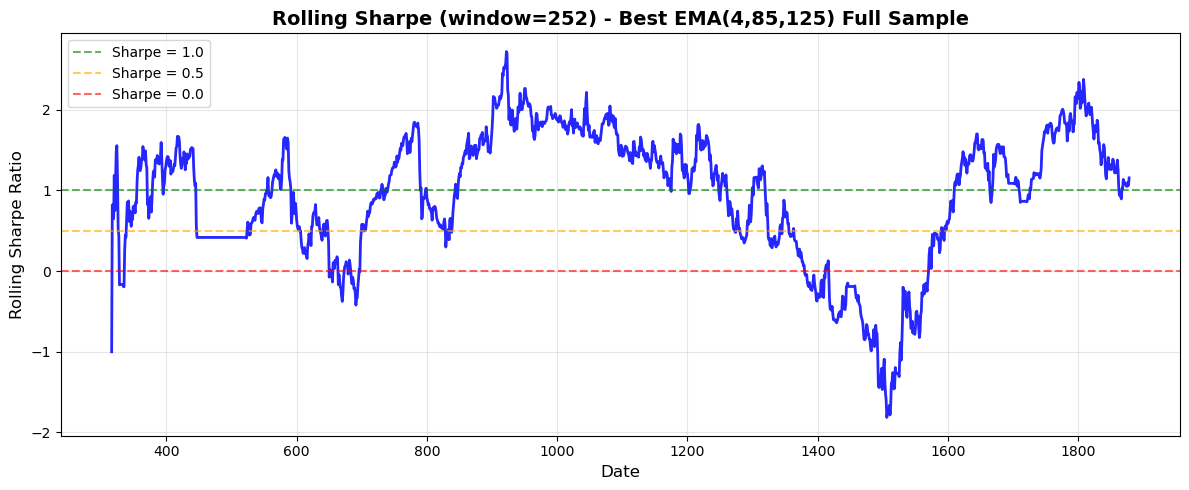

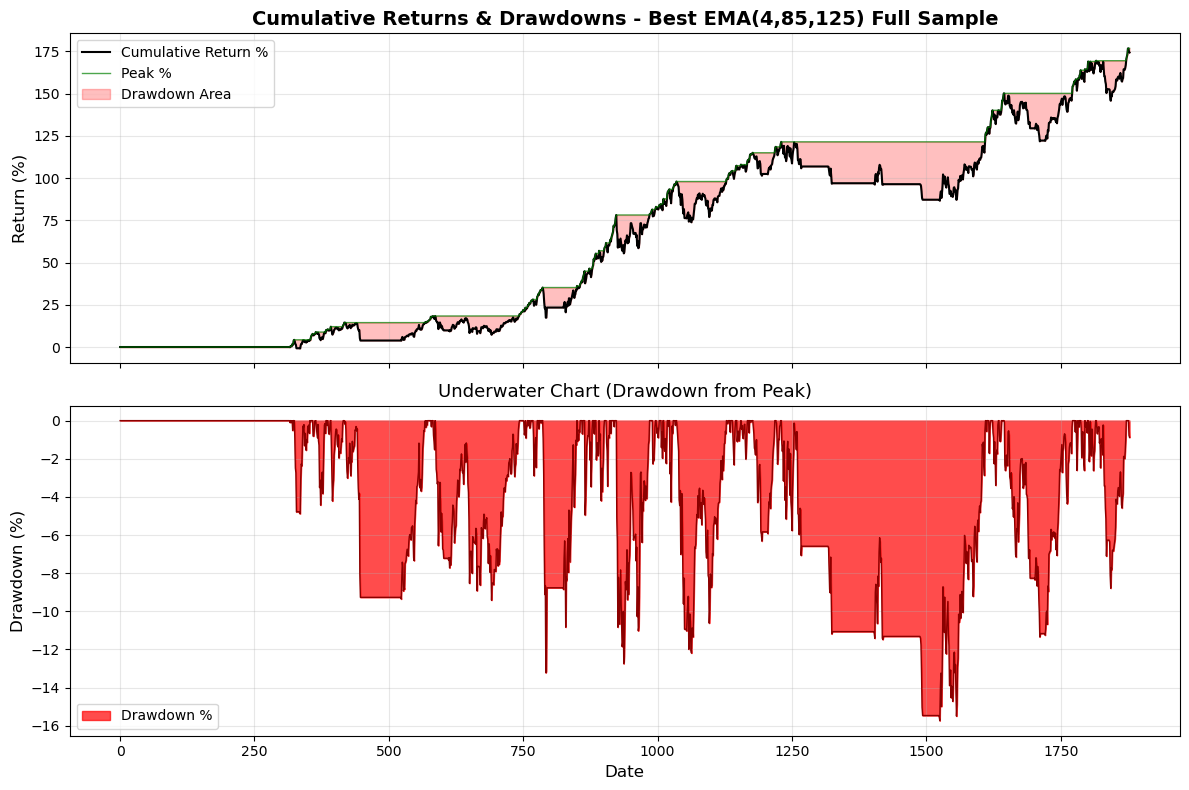

✅ Rolling Sharpe and Drawdown analysis complete for best strategy: EMA(4,85,125)


In [24]:
# FULL-SAMPLE ROLLING SHARPE + DRAWDOWNS - BEST STRATEGY

if results_df.empty:
    print("No results to visualize.")
else:
    # Get BEST strategy (highest Sharpe ratio)
    best = results_df.loc[results_df['sharpe_ratio'].idxmax()]
    ema1, ema2, ema3 = int(best['ema1_period']), int(best['ema2_period']), int(best['ema3_period'])

    # Build full-sample Triple EMA signals
    ema1_full = vbt.MA.run(close, ema1, ewm=True).ma
    ema2_full = vbt.MA.run(close, ema2, ewm=True).ma
    ema3_full = vbt.MA.run(close, ema3, ewm=True).ma
    
    # Triple EMA crossover signals (RAW)
    entries_1 = ema1_full.vbt.crossed_above(ema2_full).reindex(close.index).fillna(False)
    entries_2 = ema1_full.vbt.crossed_above(ema3_full).reindex(close.index).fillna(False)
    entries_3 = ema2_full.vbt.crossed_above(ema3_full).reindex(close.index).fillna(False)
    entries_raw = entries_1 | entries_2 | entries_3
    
    exits_1 = ema1_full.vbt.crossed_below(ema2_full).reindex(close.index).fillna(False)
    exits_2 = ema1_full.vbt.crossed_below(ema3_full).reindex(close.index).fillna(False)
    exits_3 = ema2_full.vbt.crossed_below(ema3_full).reindex(close.index).fillna(False)
    exits_raw = exits_1 | exits_2 | exits_3
    
    # ⚠️ FIX LOOKAHEAD BIAS: Shift signals by 1 bar
    entries_full = entries_raw.shift(1).fillna(False).to_numpy(dtype=bool)
    exits_full = exits_raw.shift(1).fillna(False).to_numpy(dtype=bool)

    price_full = close.to_numpy(dtype=float)

    pf_full = vbt.Portfolio.from_signals(
        close=price_full,
        entries=entries_full,
        exits=exits_full,
        init_cash=100_000,
        fees=0.0005,
        slippage=0.0005,
        freq=FREQ
    )

    # Compute returns
    ret = pf_full.returns()

    # 1) Rolling Sharpe (252-day window)
    rolling_window = max(20, min(252, max(1, len(ret) // 4)))
    if len(ret) > rolling_window:
        rolling_sharpe = ret.rolling(window=rolling_window).apply(
            lambda x: (x.mean() * 252) / (x.std() * np.sqrt(252)) if x.std() and x.std() != 0 else np.nan,
            raw=False
        )

        plt.figure(figsize=(12, 5))
        plt.plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=2, color='blue', alpha=0.85)
        plt.axhline(y=1.0, color='green', linestyle='--', alpha=0.6, label='Sharpe = 1.0')
        plt.axhline(y=0.5, color='orange', linestyle='--', alpha=0.6, label='Sharpe = 0.5')
        plt.axhline(y=0.0, color='red', linestyle='--', alpha=0.6, label='Sharpe = 0.0')
        plt.title(f'Rolling Sharpe (window={rolling_window}) - Best EMA({ema1},{ema2},{ema3}) Full Sample', fontsize=14, fontweight='bold')
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Rolling Sharpe Ratio', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Not enough data for rolling Sharpe calculation.")

    # 2) Drawdowns (underwater)
    eq = (1 + ret).cumprod()
    peak = eq.cummax()
    dd = (eq - peak) / peak

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    ax1.plot(eq.index, (eq - 1) * 100, color='black', linewidth=1.5, label='Cumulative Return %')
    ax1.plot(peak.index, (peak - 1) * 100, color='green', linewidth=1.0, alpha=0.7, label='Peak %')
    ax1.fill_between(eq.index, (eq - 1) * 100, (peak - 1) * 100, color='red', alpha=0.25, label='Drawdown Area')
    ax1.set_title(f'Cumulative Returns & Drawdowns - Best EMA({ema1},{ema2},{ema3}) Full Sample', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Return (%)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.fill_between(dd.index, dd * 100, 0, color='red', alpha=0.7, label='Drawdown %')
    ax2.plot(dd.index, dd * 100, color='darkred', linewidth=1)
    ax2.set_title('Underwater Chart (Drawdown from Peak)', fontsize=13)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('Drawdown (%)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()
    
    print(f"✅ Rolling Sharpe and Drawdown analysis complete for best strategy: EMA({ema1},{ema2},{ema3})")

In [16]:
# Debug cell - add this to see what's in trades
pf_full = vbt.Portfolio.from_signals(
    close=price_full,
    entries=entries_full,
    exits=exits_full,
    init_cash=100_000,
    fees=0.0005,
    slippage=0.0005,
    freq=FREQ
)

print("Trades object type:", type(pf_full.trades))
print("\nAvailable attributes:")
print([attr for attr in dir(pf_full.trades) if not attr.startswith('_')])

print("\nTrades records:")
print(pf_full.trades.records_readable if hasattr(pf_full.trades, 'records_readable') else pf_full.trades.records)

Trades object type: <class 'vectorbt.portfolio.trades.ExitTrades'>

Available attributes:
['apply', 'apply_mask', 'avg_duration', 'build_field_config_doc', 'build_metrics_doc', 'build_subplots_doc', 'close', 'closed', 'col', 'col_arr', 'col_mapper', 'config', 'copy', 'count', 'coverage', 'deep_getattr', 'direction', 'dumps', 'duration', 'end_idx', 'entry_fees', 'entry_idx', 'entry_price', 'exit_fees', 'exit_idx', 'exit_price', 'expectancy', 'field_config', 'from_orders', 'from_ts', 'get_apply_mapping_arr', 'get_by_col_idxs', 'get_field_arr', 'get_field_mapping', 'get_field_name', 'get_field_setting', 'get_field_title', 'get_map_field', 'get_map_field_to_index', 'id', 'id_arr', 'idx_arr', 'iloc', 'indexing_func', 'indexing_func_meta', 'indexing_kwargs', 'is_sorted', 'load', 'loads', 'loc', 'long', 'losing', 'losing_streak', 'map', 'map_array', 'map_field', 'max_duration', 'metrics', 'open', 'override_field_config_doc', 'override_metrics_doc', 'override_subplots_doc', 'parent_id', 'plot'

C:\Users\mkova\AppData\Local\Temp\ipykernel_20516\3596728499.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  entries_full = entries_raw.shift(1).fillna(False).reindex(close.index).fillna(False).to_numpy(dtype=bool)
C:\Users\mkova\AppData\Local\Temp\ipykernel_20516\3596728499.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  exits_full = exits_raw.shift(1).fillna(False).reindex(close.index).fillna(False).to_numpy(dtype=bool)


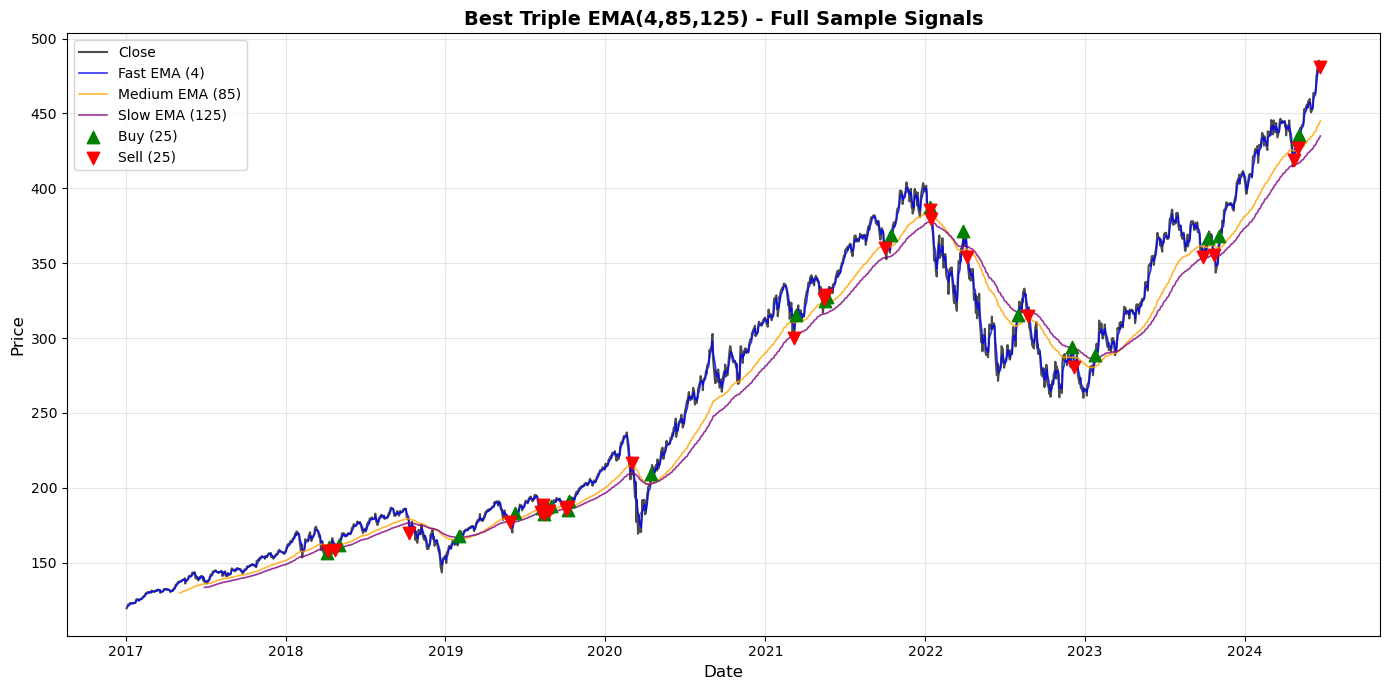

Total trades: 25
Buy signals plotted: 25
Sell signals plotted: 25


In [26]:
# STEP 5C: VISUALS ONLY (Signals + Equity Curves) - BEST STRATEGY

if results_df.empty:
    print("No results to visualize.")
else:
    # Get BEST strategy (highest Sharpe ratio)
    best = results_df.loc[results_df['sharpe_ratio'].idxmax()]
    ema1, ema2, ema3 = int(best['ema1_period']), int(best['ema2_period']), int(best['ema3_period'])

    # Build full sample EMAs and signals for Triple EMA
    ema1_full = vbt.MA.run(close, ema1, ewm=True).ma
    ema2_full = vbt.MA.run(close, ema2, ewm=True).ma
    ema3_full = vbt.MA.run(close, ema3, ewm=True).ma
    
    # Triple EMA crossover signals (RAW) - CONSISTENT WITH GRID SEARCH
    e1 = ema1_full.vbt.crossed_above(ema2_full).reindex(close.index).fillna(False)
    e2 = ema1_full.vbt.crossed_above(ema3_full).reindex(close.index).fillna(False)
    e3 = ema2_full.vbt.crossed_above(ema3_full).reindex(close.index).fillna(False)
    entries_raw = e1 | e2 | e3
    
    x1 = ema1_full.vbt.crossed_below(ema2_full).reindex(close.index).fillna(False)
    x2 = ema1_full.vbt.crossed_below(ema3_full).reindex(close.index).fillna(False)
    x3 = ema2_full.vbt.crossed_below(ema3_full).reindex(close.index).fillna(False)
    exits_raw = x1 | x2 | x3
    
    # FIX LOOKAHEAD BIAS: Shift signals by 1 bar
    entries_full = entries_raw.shift(1).fillna(False).reindex(close.index).fillna(False).to_numpy(dtype=bool)
    exits_full = exits_raw.shift(1).fillna(False).reindex(close.index).fillna(False).to_numpy(dtype=bool)

    # Build portfolio first (needed for actual trades)
    price_full = close.to_numpy(dtype=float)
    pf_full = vbt.Portfolio.from_signals(
        close=price_full,
        entries=entries_full,
        exits=exits_full,
        init_cash=100_000,
        fees=0.0005,
        slippage=0.0005,
        freq=FREQ
    )

    # Get ACTUAL trades (not raw signals)
    trades_df = pf_full.trades.records_readable
    entry_idxs = trades_df['Entry Timestamp'].values  # These are integer positions
    exit_idxs = trades_df['Exit Timestamp'].values
    entry_prices = trades_df['Avg Entry Price'].values
    exit_prices = trades_df['Avg Exit Price'].values
    
    # Convert index positions to dates
    buy_dates = close.index[entry_idxs]
    sell_dates = close.index[exit_idxs]

    # 1) Price + Triple EMAs + ACTUAL trade signals
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(close.index, close.values, label='Close', color='black', linewidth=1.5, alpha=0.7)
    ax.plot(close.index, ema1_full.values, label=f'Fast EMA ({ema1})', color='blue', alpha=0.8, linewidth=1.2)
    ax.plot(close.index, ema2_full.values, label=f'Medium EMA ({ema2})', color='orange', alpha=0.8, linewidth=1.2)
    ax.plot(close.index, ema3_full.values, label=f'Slow EMA ({ema3})', color='purple', alpha=0.8, linewidth=1.2)

    ax.scatter(buy_dates, entry_prices, marker='^', color='green', s=80, label=f'Buy ({len(buy_dates)})', zorder=5)
    ax.scatter(sell_dates, exit_prices, marker='v', color='red', s=80, label=f'Sell ({len(sell_dates)})', zorder=5)

    ax.set_title(f'Best Triple EMA({ema1},{ema2},{ema3}) - Full Sample Signals', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()
    
    print(f"Total trades: {len(trades_df)}")
    print(f"Buy signals plotted: {len(buy_dates)}")
    print(f"Sell signals plotted: {len(sell_dates)}")

C:\Users\mkova\AppData\Local\Temp\ipykernel_20516\383210688.py:53: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  entries_shifted = pd.Series(np.asarray(entries_raw).ravel(), index=full_close.index, dtype=bool).shift(1).fillna(False)
C:\Users\mkova\AppData\Local\Temp\ipykernel_20516\383210688.py:54: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  exits_shifted = pd.Series(np.asarray(exits_raw).ravel(), index=full_close.index, dtype=bool).shift(1).fillna(False)


Total trades plotted: 25
Win Rate: 60.0% (15W / 10L)
Avg Win: 8.95% | Avg Loss: -2.04%
Max Win: 42.95% | Max Loss: -4.80%


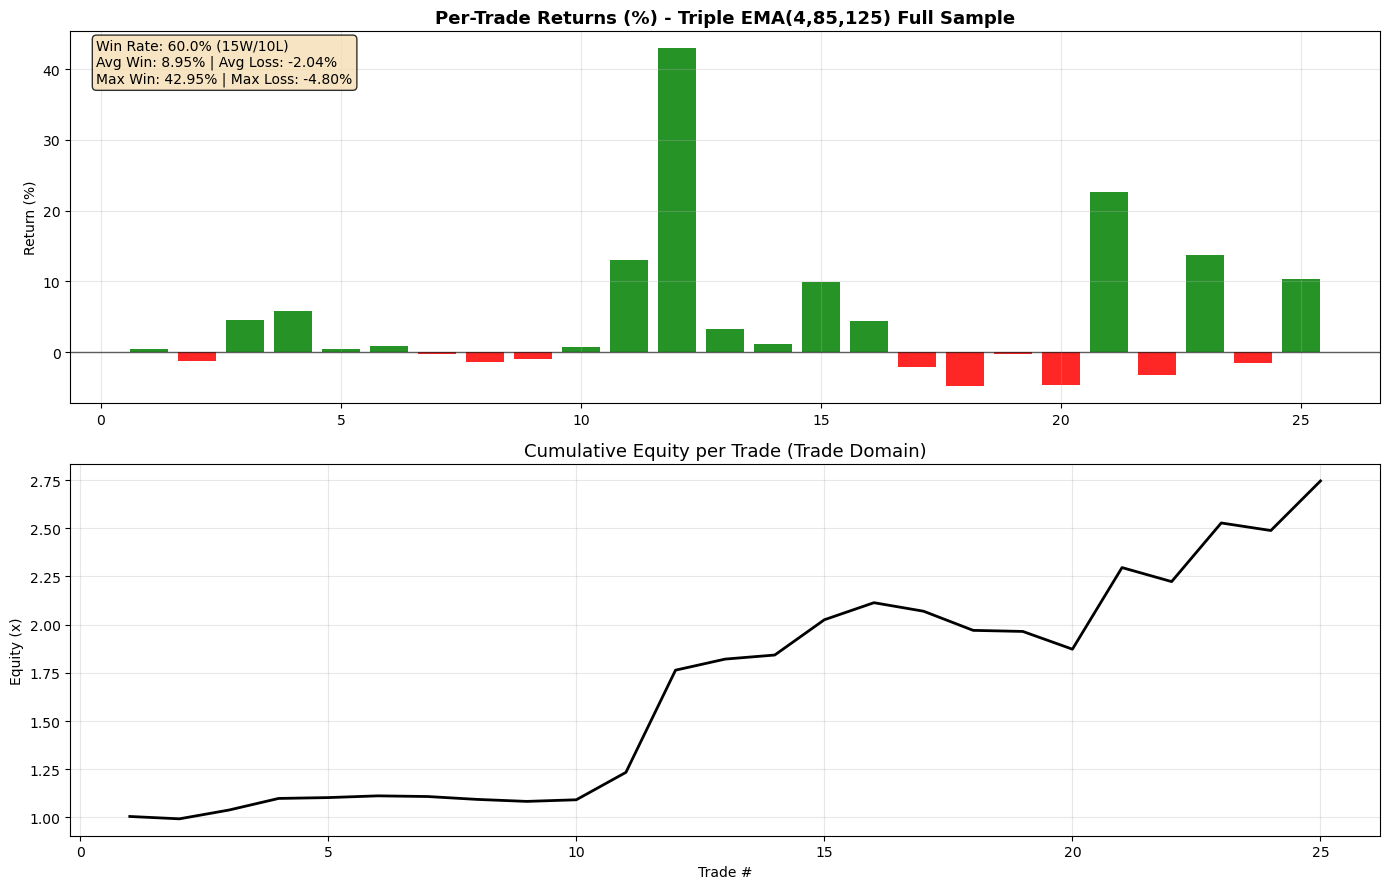

In [27]:
# FULL-SAMPLE TRADE-BY-TRADE RETURNS (BAR) + CUMULATIVE PER-TRADE EQUITY — ALL TRADESbt

if 'FREQ' not in globals():
    FREQ = "1D"

# Resolve full close series
if 'close' in globals() and hasattr(close, 'index'):
    full_close = close.astype(float)
else:
    if isinstance(stock_data.columns, pd.MultiIndex):
        if ('Close', TICKER) in stock_data.columns:
            full_close = stock_data[('Close', TICKER)].astype(float).rename(TICKER)
        else:
            found = None
            for col in stock_data.columns:
                if isinstance(col, tuple) and ('Close' in col):
                    found = col; break
            if found is None:
                for col in stock_data.columns:
                    if 'Close' in str(col):
                        found = col; break
            if found is None:
                raise KeyError("Could not find a 'Close' column for full-sample trade plot.")
            full_close = stock_data[found].astype(float).rename(TICKER)
    else:
        full_close = stock_data['Close'].astype(float).rename(TICKER)

# Best params
if 'results_df' not in globals() or results_df.empty:
    raise ValueError("results_df is empty or missing. Run the grid search first.")
best = results_df.loc[results_df['sharpe_ratio'].idxmax()]
ema1, ema2, ema3 = int(best['ema1_period']), int(best['ema2_period']), int(best['ema3_period'])

# Indicators
ema1_full = vbt.MA.run(full_close, ema1, ewm=True)
ema2_full = vbt.MA.run(full_close, ema2, ewm=True)
ema3_full = vbt.MA.run(full_close, ema3, ewm=True)

# Signals (MATCH GRID SEARCH LOGIC - simple OR, no extra conditions)
entries_raw = (
    ema1_full.ma_crossed_above(ema2_full.ma) |
    ema1_full.ma_crossed_above(ema3_full.ma) |
    ema2_full.ma_crossed_above(ema3_full.ma)
)
exits_raw = (
    ema1_full.ma_crossed_below(ema2_full.ma) |
    ema1_full.ma_crossed_below(ema3_full.ma) |
    ema2_full.ma_crossed_below(ema3_full.ma)
)

# ⚠️ FIX LOOKAHEAD BIAS: Shift signals by 1 bar
# Convert to plain arrays AND shift
entries_shifted = pd.Series(np.asarray(entries_raw).ravel(), index=full_close.index, dtype=bool).shift(1).fillna(False)
exits_shifted = pd.Series(np.asarray(exits_raw).ravel(), index=full_close.index, dtype=bool).shift(1).fillna(False)

entries_full = pd.Series(np.asarray(entries_shifted).ravel(), index=full_close.index, dtype=bool)
exits_full = pd.Series(np.asarray(exits_shifted).ravel(), index=full_close.index, dtype=bool)

# Backtest
pf_full = vbt.Portfolio.from_signals(
    close=full_close.to_numpy(dtype=float),
    entries=entries_full,
    exits=exits_full,
    init_cash=100_000,
    fees=0.0005,
    slippage=0.0005,
    freq=FREQ
)

# Trade-by-trade returns (ALL trades)
trades = pf_full.trades
trade_returns = trades.returns.values if hasattr(trades.returns, 'values') else np.asarray(trades.returns)
trade_returns = np.asarray(trade_returns).ravel()  # ensure 1D

if trade_returns.size == 0:
    print("No trades to plot.")
else:
    # Calculate statistics
    winning_trades = trade_returns[trade_returns > 0]
    losing_trades = trade_returns[trade_returns < 0]
    
    total_trades = len(trade_returns)
    win_count = len(winning_trades)
    loss_count = len(losing_trades)
    win_rate = (win_count / total_trades * 100) if total_trades > 0 else 0
    
    avg_win_pct = (winning_trades.mean() * 100) if len(winning_trades) > 0 else 0
    avg_loss_pct = (losing_trades.mean() * 100) if len(losing_trades) > 0 else 0
    max_win_pct = (winning_trades.max() * 100) if len(winning_trades) > 0 else 0
    max_loss_pct = (losing_trades.min() * 100) if len(losing_trades) > 0 else 0
    
    print(f"Total trades plotted: {total_trades}")
    print(f"Win Rate: {win_rate:.1f}% ({win_count}W / {loss_count}L)")
    print(f"Avg Win: {avg_win_pct:.2f}% | Avg Loss: {avg_loss_pct:.2f}%")
    print(f"Max Win: {max_win_pct:.2f}% | Max Loss: {max_loss_pct:.2f}%")
    
    equity_per_trade = np.cumprod(1.0 + trade_returns)

    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

    # Per-trade returns (%), all trades
    x = np.arange(1, trade_returns.size + 1)
    colors = np.where(trade_returns >= 0, 'green', 'red')
    axes[0].bar(x, trade_returns * 100.0, color=colors, alpha=0.85, width=0.8)
    axes[0].axhline(0, color='black', linewidth=1, alpha=0.6)
    
    # Add statistics text box on the chart
    stats_text = (
        f'Win Rate: {win_rate:.1f}% ({win_count}W/{loss_count}L)\n'
        f'Avg Win: {avg_win_pct:.2f}% | Avg Loss: {avg_loss_pct:.2f}%\n'
        f'Max Win: {max_win_pct:.2f}% | Max Loss: {max_loss_pct:.2f}%'
    )
    axes[0].text(0.02, 0.98, stats_text, transform=axes[0].transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    axes[0].set_title(f'Per-Trade Returns (%) - Triple EMA({ema1},{ema2},{ema3}) Full Sample', 
                     fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Return (%)')
    axes[0].grid(True, alpha=0.3)

    # Cumulative equity per trade
    axes[1].plot(x, equity_per_trade, color='black', linewidth=2)
    axes[1].set_title('Cumulative Equity per Trade (Trade Domain)', fontsize=13)
    axes[1].set_xlabel('Trade #')
    axes[1].set_ylabel('Equity (x)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [28]:
#PARAMETER SENSITIVITY TABLE

if results_df.empty:
    print("No results available for sensitivity analysis.")
else:
    # Get BEST strategy (highest Sharpe ratio)
    best = results_df.loc[results_df['sharpe_ratio'].idxmax()]
    ema1, ema2, ema3 = int(best['ema1_period']), int(best['ema2_period']), int(best['ema3_period'])

    print(f"Parameter Sensitivity Analysis for Best EMA({ema1},{ema2},{ema3})")
    print("=" * 80)

    # Create sensitivity ranges (±15 around each parameter)
    fast_candidates = list(range(max(2, ema1 - 15), ema1 + 16))
    medium_candidates = list(range(max(3, ema2 - 15), ema2 + 16))
    slow_candidates = list(range(max(4, ema3 - 15), ema3 + 16))
    
    # Test variations: vary one parameter at a time
    combos = ([(f, ema2, ema3) for f in fast_candidates] +
              [(ema1, m, ema3) for m in medium_candidates if m != ema2] +
              [(ema1, ema2, s) for s in slow_candidates if s != ema3])

    price_np = train_close.to_numpy(dtype=float)
    idx = train_close.index

    def series_to_np_bool(s: pd.Series) -> np.ndarray:
        return s.reindex(idx).where(s.reindex(idx).notna(), False).astype(bool).to_numpy(dtype=bool)

    def eval_combo(e1: int, e2: int, e3: int) -> dict:
        fma = vbt.MA.run(train_close, e1, ewm=True).ma
        mma = vbt.MA.run(train_close, e2, ewm=True).ma
        sma = vbt.MA.run(train_close, e3, ewm=True).ma
        
        # Triple EMA crossover (RAW) - CONSISTENT WITH GRID SEARCH
        e1_sig = fma.vbt.crossed_above(mma).reindex(idx).fillna(False)
        e2_sig = fma.vbt.crossed_above(sma).reindex(idx).fillna(False)
        e3_sig = mma.vbt.crossed_above(sma).reindex(idx).fillna(False)
        e_raw = e1_sig | e2_sig | e3_sig
        
        x1_sig = fma.vbt.crossed_below(mma).reindex(idx).fillna(False)
        x2_sig = fma.vbt.crossed_below(sma).reindex(idx).fillna(False)
        x3_sig = mma.vbt.crossed_below(sma).reindex(idx).fillna(False)
        x_raw = x1_sig | x2_sig | x3_sig
        
        # FIX LOOKAHEAD BIAS: Shift signals by 1 bar
        e_shifted = e_raw.shift(1).where(e_raw.shift(1).notna(), False).astype(bool)
        x_shifted = x_raw.shift(1).where(x_raw.shift(1).notna(), False).astype(bool)
        
        e = series_to_np_bool(e_shifted)
        x = series_to_np_bool(x_shifted)

        pf = vbt.Portfolio.from_signals(
            close=price_np, entries=e, exits=x,
            init_cash=100_000, fees=0.0005, slippage=0.0005, freq=FREQ
        )

        total_return = float(pf.total_return())
        sharpe = float(pf.sharpe_ratio(freq=FREQ))
        sortino = float(pf.sortino_ratio(freq=FREQ))
        mdd = float(pf.max_drawdown())
        vol = float(pf.annualized_volatility(freq=FREQ))

        trades = pf.trades
        ntr = len(trades)
        win_rate_pct = np.nan
        profit_factor = np.nan
        expectancy = 0.0
        if ntr > 0:
            tr = trades.returns.values if hasattr(trades.returns, 'values') else np.array(trades.returns)
            if tr.size > 0:
                pos = tr[tr > 0]
                neg = tr[tr < 0]
                win_rate_pct = (len(pos) / len(tr)) * 100 if len(tr) else np.nan
                gains = pos.sum() if len(pos) else 0.0
                losses = abs(neg.sum()) if len(neg) else 0.0
                profit_factor = gains / losses if losses > 0 else np.inf
                expectancy = float(tr.mean())

        return {
            'ema1': e1, 'ema2': e2, 'ema3': e3,
            'sharpe': sharpe, 'sortino': sortino,
            'total_return': total_return, 'max_drawdown': mdd, 'volatility': vol,
            'total_trades': ntr, 'win_rate_pct': win_rate_pct,
            'profit_factor': profit_factor, 'expectancy': expectancy
        }

    rows = []
    for combo in combos:
        try:
            rows.append(eval_combo(*combo))
        except Exception:
            pass

    if not rows:
        print("No sensitivity results computed.")
    else:
        sens = pd.DataFrame(rows)

        # Show as a table
        cols = ['ema1','ema2','ema3','sharpe','sortino','total_return','max_drawdown','volatility',
                'total_trades','win_rate_pct','profit_factor','expectancy']
        sens_table = sens[cols].sort_values(['ema1','ema2','ema3'])
        
        print(f"Sensitivity Results ({len(sens_table)} variations tested):\n")
        display(sens_table)

        # Compact variation summary
        metric_cols = ['sharpe','sortino','total_return','max_drawdown','volatility',
                       'win_rate_pct','profit_factor','expectancy']
        summary = sens_table[metric_cols].agg(['mean','std','min','max']).T
        
        print("Sensitivity Summary (mean / std / min / max):")
        print(summary.round(4).to_string())



Parameter Sensitivity Analysis for Best EMA(4,85,125)
Sensitivity Results (78 variations tested):



,ema1,ema2,ema3,sharpe,sortino,total_return,max_drawdown,volatility,total_trades,win_rate_pct,profit_factor,expectancy
0,2,85,125,1.039812,1.410499,0.701183,-0.159687,0.181431,23,56.521739,5.662463,0.025387
1,3,85,125,1.182648,1.624862,0.855159,-0.159687,0.183582,18,55.555556,11.251904,0.039547
18,4,70,125,0.946172,1.266203,0.592395,-0.152095,0.175679,16,56.250000,6.633193,0.032140
19,4,71,125,0.953040,1.276836,0.600095,-0.152095,0.176137,17,58.823529,6.468136,0.030538
20,4,72,125,0.988652,1.326936,0.632669,-0.152095,0.176453,16,62.500000,9.522335,0.033670
...,...,...,...,...,...,...,...,...,...,...,...,...
13,15,85,125,1.225411,1.696632,0.972707,-0.183180,0.195231,6,83.333333,30.294918,0.140104
14,16,85,125,1.212364,1.678395,0.957466,-0.183180,0.195264,6,83.333333,30.008768,0.138736
15,17,85,125,1.003763,1.348886,0.756159,-0.261418,0.202289,5,60.000000,13.066761,0.142525
16,18,85,125,0.959451,1.287084,0.710368,-0.261418,0.202823,4,75.000000,20.445402,0.170637


Sensitivity Summary (mean / std / min / max):
                  mean     std      min      max
sharpe          1.2091  0.1075   0.9405   1.3356
sortino         1.6609  0.1607   1.2609   1.8684
total_return    0.8818  0.1056   0.5924   1.0995
max_drawdown   -0.1518  0.0311  -0.2673  -0.1322
volatility      0.1831  0.0066   0.1757   0.2028
win_rate_pct   66.9848  7.8302  41.6667  83.3333
profit_factor  15.9306  7.1817   5.6625  41.7199
expectancy      0.0640  0.0378   0.0254   0.1851
